In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/asthem014/mmrdr-dr-detection/MMRDR.zip.005
/kaggle/input/datasets/asthem014/mmrdr-dr-detection/README.md
/kaggle/input/datasets/asthem014/mmrdr-dr-detection/MMRDR.zip.008
/kaggle/input/datasets/asthem014/mmrdr-dr-detection/MMRDR.zip.001
/kaggle/input/datasets/asthem014/mmrdr-dr-detection/MMRDR.zip.009
/kaggle/input/datasets/asthem014/mmrdr-dr-detection/MMRDR.zip.003
/kaggle/input/datasets/asthem014/mmrdr-dr-detection/MMRDR.zip.007
/kaggle/input/datasets/asthem014/mmrdr-dr-detection/MMRDR.zip.002
/kaggle/input/datasets/asthem014/mmrdr-dr-detection/MMRDR.zip.006
/kaggle/input/datasets/asthem014/mmrdr-dr-detection/MMRDR.zip.004


In [2]:
import os

CFP_PATH = "/kaggle/working/MMRDR-CFP/MMRDR-CFP"

print("CFP exists:", os.path.exists(CFP_PATH))

if os.path.exists(CFP_PATH):
    print("Contents:", os.listdir(CFP_PATH))
    print("Images:", len(os.listdir(os.path.join(CFP_PATH, "img"))))

CFP exists: False


In [3]:
import os

DATASET_PATH = "/kaggle/input/datasets/asthem014/mmrdr-dr-detection"

print("Dataset exists:", os.path.exists(DATASET_PATH))
print(os.listdir(DATASET_PATH))

Dataset exists: True
['MMRDR.zip.005', 'README.md', 'MMRDR.zip.008', 'MMRDR.zip.001', 'MMRDR.zip.009', 'MMRDR.zip.003', 'MMRDR.zip.007', 'MMRDR.zip.002', 'MMRDR.zip.006', 'MMRDR.zip.004']


In [4]:
import subprocess
import os

DATASET_PATH = "/kaggle/input/datasets/asthem014/mmrdr-dr-detection"
OUTPUT_PATH = "/kaggle/working/MMRDR-CFP"

os.makedirs(OUTPUT_PATH, exist_ok=True)

cmd = [
    "7z", "x",
    f"{DATASET_PATH}/MMRDR.zip.001",
    "MMRDR-CFP/*",
    "-o" + OUTPUT_PATH,
    "-y"
]

print("Starting CFP extraction...")
print("This may take a few minutes.\n")

result = subprocess.run(cmd)

print("\nExtraction finished.")
print("Return code:", result.returncode)

Starting CFP extraction...
This may take a few minutes.


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,4 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
1 file, 2097152000 bytes (2000 MiB)

Extracting archive: /kaggle/input/datasets/asthem014/mmrdr-dr-detection/MMRDR.zip.001
--
Path = /kaggle/input/datasets/asthem014/mmrdr-dr-detection/MMRDR.zip.001
Type = Split
Physical Size = 2097152000
Volumes = 9
Total Physical Size = 18610317731
----
Path = MMRDR.zip
Size = 18610317731
--
Path = MMRDR.zip
Type = zip
Physical Size = 18610317731
64-bit = +

Everything is Ok

Folders: 1
Files: 11119
Size:       7632191054
Compressed: 18610317731

Extraction finished.
Return code: 0


In [5]:
import os
import pandas as pd

CFP_PATH = "/kaggle/working/MMRDR-CFP/MMRDR-CFP"
IMG_PATH = os.path.join(CFP_PATH, "img")
CSV_PATH = os.path.join(CFP_PATH, "FP.csv")

print("CFP path exists:", os.path.exists(CFP_PATH))
print("Image folder exists:", os.path.exists(IMG_PATH))
print("FP.csv exists:", os.path.exists(CSV_PATH))

cfp_df = pd.read_csv(CSV_PATH)

print("\nDataset shape:", cfp_df.shape)
print("\nColumns:")
print(cfp_df.columns.tolist())

print("\nFirst 5 rows:")
display(cfp_df.head())

CFP path exists: True
Image folder exists: True
FP.csv exists: True

Dataset shape: (11118, 5)

Columns:
['type', 'image', 'grade', 'lesion', 'lr']

First 5 rows:


,type,image,grade,lesion,lr
0,FP,img/tr000001.jpg,0,"[0, 0, 0, 0, 0, 0, 0]",0
1,FP,img/tr000002.jpg,3,"[1, 1, 1, 0, 0, 0, 0]",1
2,FP,img/tr000003.jpg,2,"[1, 1, 1, 0, 0, 0, 0]",0
3,FP,img/tr000004.jpg,1,"[1, 0, 0, 0, 0, 0, 0]",1
4,FP,img/tr000005.jpg,0,"[0, 0, 0, 0, 0, 0, 0]",0


In [6]:
import ast
import pandas as pd

# Convert lesion strings into lists
cfp_df["lesion_list"] = cfp_df["lesion"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Check the first few lesion vectors
print("Example lesion vectors:")
for i in range(10):
    print(i, cfp_df.loc[i, "lesion_list"])

# Check that every vector has exactly 7 elements
lengths = cfp_df["lesion_list"].apply(len)

print("\nLesion vector lengths:")
print(lengths.value_counts().sort_index())

# Distribution of each of the 7 positions
lesion_matrix = pd.DataFrame(
    cfp_df["lesion_list"].tolist(),
    columns=[f"lesion_{i}" for i in range(7)]
)

print("\nDistribution of all 7 lesion positions:")
display(lesion_matrix.sum().to_frame("positive_count"))

print("\nUnique values:")
display(lesion_matrix.nunique().to_frame("unique_values"))

Example lesion vectors:
0 [0, 0, 0, 0, 0, 0, 0]
1 [1, 1, 1, 0, 0, 0, 0]
2 [1, 1, 1, 0, 0, 0, 0]
3 [1, 0, 0, 0, 0, 0, 0]
4 [0, 0, 0, 0, 0, 0, 0]
5 [1, 1, 1, 0, 0, 0, 0]
6 [1, 0, 1, 0, 0, 0, 0]
7 [0, 0, 0, 0, 0, 0, 0]
8 [0, 0, 0, 0, 0, 0, 0]
9 [0, 0, 0, 0, 0, 0, 0]

Lesion vector lengths:
lesion_list
7    11118
Name: count, dtype: int64

Distribution of all 7 lesion positions:


,positive_count
lesion_0,4398
lesion_1,2648
lesion_2,2580
lesion_3,236
lesion_4,556
lesion_5,358
lesion_6,93



Unique values:


,unique_values
lesion_0,2
lesion_1,2
lesion_2,2
lesion_3,2
lesion_4,2
lesion_5,2
lesion_6,2


In [7]:
import os

README_PATH = "/kaggle/input/datasets/asthem014/mmrdr-dr-detection/README.md"

print("README exists:", os.path.exists(README_PATH))

if os.path.exists(README_PATH):
    with open(README_PATH, "r", encoding="utf-8", errors="ignore") as f:
        readme_text = f.read()

    print(readme_text[:12000])

README exists: True
# MMRDR: Multi-Modal Retinal images for in-depth DR analysis

## Dataset Structure

```bash
MMRDR/
├── MMRDR-CFP/            # Color Fundus Photography
│   ├── img/              # CFP images (JPEG format)
│   │   ├── tr000001.jpg  # Training case 1
│   │   ├── tr000002.jpg  # Training case 2
│   │   ├── ...
│   │   ├── ts000001.jpg  # Testing case 1
│   │   └── ... 
│   └── FP.csv            # Metadata & annotations
│
├── MMRDR-OCT/            # Optical Coherence Tomography
│   ├── img/              # OCT images (JPEG format)
│   │   ├── tr000001.jpg  # Training case 1
│   │   ├── ...
│   │   ├── ts000001.jpg  # Testing case 1
│   │   └── ... 
│   └── OCT.csv           # Metadata & annotations
│
└── MMRDR-UWF/            # Ultra-WideField Imaging
    ├── img/              # UWF images (JPEG format)
    │   ├── tr000001.jpg  # Training case 1
    │   ├── ...
    │   ├── ts000001.jpg  # Testing case 1
    │   └── ... 
    └── UWF.csv           # Metadata & annotations

In [8]:
# Official lesion names from MMRDR README

lesion_names = [
    "microaneurysm",
    "hard_exudate",
    "intraretinal_hemorrhage",
    "vb_irma",
    "neovascularization",
    "vitreous_hemorrhage",
    "retinal_detachment"
]

# Create 7 binary lesion columns
for i, name in enumerate(lesion_names):
    cfp_df[name] = lesion_matrix[f"lesion_{i}"].astype("int8")

# Keep only the columns needed for modeling
cfp_clean = cfp_df[
    [
        "image",
        "grade",
        "lr",
        "microaneurysm",
        "hard_exudate",
        "intraretinal_hemorrhage",
        "vb_irma",
        "neovascularization",
        "vitreous_hemorrhage",
        "retinal_detachment"
    ]
].copy()

print("Clean CFP dataframe shape:", cfp_clean.shape)

display(cfp_clean.head())

Clean CFP dataframe shape: (11118, 10)


,image,grade,lr,microaneurysm,hard_exudate,intraretinal_hemorrhage,vb_irma,neovascularization,vitreous_hemorrhage,retinal_detachment
0,img/tr000001.jpg,0,0,0,0,0,0,0,0,0
1,img/tr000002.jpg,3,1,1,1,1,0,0,0,0
2,img/tr000003.jpg,2,0,1,1,1,0,0,0,0
3,img/tr000004.jpg,1,1,1,0,0,0,0,0,0
4,img/tr000005.jpg,0,0,0,0,0,0,0,0,0


In [9]:
print("Missing values:")
display(cfp_clean.isnull().sum())

print("\nDR grade distribution:")
display(cfp_clean["grade"].value_counts().sort_index())

print("\nLesion positive counts:")
display(cfp_clean[lesion_names].sum().to_frame("positive_count"))

print("\nData types:")
display(cfp_clean.dtypes)

Missing values:


image                      0
grade                      0
lr                         0
microaneurysm              0
hard_exudate               0
intraretinal_hemorrhage    0
vb_irma                    0
neovascularization         0
vitreous_hemorrhage        0
retinal_detachment         0
dtype: int64


DR grade distribution:


grade
0    6579
1    1302
2    1959
3     603
4     675
Name: count, dtype: int64


Lesion positive counts:


,positive_count
microaneurysm,4398
hard_exudate,2648
intraretinal_hemorrhage,2580
vb_irma,236
neovascularization,556
vitreous_hemorrhage,358
retinal_detachment,93



Data types:


image                      object
grade                       int64
lr                          int64
microaneurysm                int8
hard_exudate                 int8
intraretinal_hemorrhage      int8
vb_irma                      int8
neovascularization           int8
vitreous_hemorrhage          int8
retinal_detachment           int8
dtype: object

In [10]:
print("DR grade distribution:")
display(cfp_clean["grade"].value_counts().sort_index())

print("\nLesion positive counts:")
display(cfp_clean[lesion_names].sum().to_frame("positive_count"))

print("\nData types:")
display(cfp_clean.dtypes)

DR grade distribution:


grade
0    6579
1    1302
2    1959
3     603
4     675
Name: count, dtype: int64


Lesion positive counts:


,positive_count
microaneurysm,4398
hard_exudate,2648
intraretinal_hemorrhage,2580
vb_irma,236
neovascularization,556
vitreous_hemorrhage,358
retinal_detachment,93



Data types:


image                      object
grade                       int64
lr                          int64
microaneurysm                int8
hard_exudate                 int8
intraretinal_hemorrhage      int8
vb_irma                      int8
neovascularization           int8
vitreous_hemorrhage          int8
retinal_detachment           int8
dtype: object

## 3. Train / Validation / Test Split

To ensure a reliable evaluation, the CFP dataset is divided into training,
validation, and test sets using stratified sampling based on the diabetic
retinopathy grade.

- Training: 80%
- Validation: 10%
- Test: 10%
- Stratification variable: DR grade
- Random seed: 42

In [11]:
from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temporary
train_df, temp_df = train_test_split(
    cfp_clean,
    test_size=0.20,
    stratify=cfp_clean["grade"],
    random_state=42
)

# Second split: 10% validation, 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["grade"],
    random_state=42
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Dataset sizes:")
print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

print("\nGrade distribution:")
print("\nTrain:")
display(train_df["grade"].value_counts().sort_index())

print("\nValidation:")
display(val_df["grade"].value_counts().sort_index())

print("\nTest:")
display(test_df["grade"].value_counts().sort_index())

Dataset sizes:
Train      : 8894
Validation : 1112
Test       : 1112

Grade distribution:

Train:


grade
0    5263
1    1042
2    1567
3     482
4     540
Name: count, dtype: int64


Validation:


grade
0    658
1    130
2    196
3     60
4     68
Name: count, dtype: int64


Test:


grade
0    658
1    130
2    196
3     61
4     67
Name: count, dtype: int64

In [12]:
# Save split metadata for reproducibility

SPLIT_PATH = "/kaggle/working"

train_df.to_csv(f"{SPLIT_PATH}/cfp_train.csv", index=False)
val_df.to_csv(f"{SPLIT_PATH}/cfp_val.csv", index=False)
test_df.to_csv(f"{SPLIT_PATH}/cfp_test.csv", index=False)

print("Split files saved successfully:")
print("Train      :", f"{SPLIT_PATH}/cfp_train.csv")
print("Validation :", f"{SPLIT_PATH}/cfp_val.csv")
print("Test       :", f"{SPLIT_PATH}/cfp_test.csv")

Split files saved successfully:
Train      : /kaggle/working/cfp_train.csv
Validation : /kaggle/working/cfp_val.csv
Test       : /kaggle/working/cfp_test.csv


## 4. Image Preprocessing

The CFP retinal images are prepared for deep learning using a consistent
preprocessing pipeline.

The preprocessing pipeline will:

1. Load each retinal image from its file path.
2. Convert images to RGB format.
3. Resize images to a fixed resolution.
4. Convert images into PyTorch tensors.
5. Normalize pixel values using ImageNet normalization.

Training images will additionally use controlled data augmentation,
while validation and test images will use only deterministic preprocessing.

In [13]:
import torch
from torchvision import transforms

IMG_SIZE = 224

# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation / Test transformations
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image size:", IMG_SIZE)
print("Transforms created successfully.")

Image size: 224
Transforms created successfully.


## 5. PyTorch Dataset and DataLoader

A custom PyTorch `Dataset` is used to connect the CFP dataframe with the retinal image files.

Each sample will provide:

* **Image:** preprocessed CFP retinal image tensor
* **Grade:** DR severity class (0–4)
* **Lesions:** seven binary lesion targets

The DR grade will be used as the primary classification target, while the lesion labels will later support auxiliary multi-task learning.


In [14]:
from PIL import Image
from torch.utils.data import Dataset

IMAGE_ROOT = "/kaggle/working/MMRDR-CFP/MMRDR-CFP"


class CFPDataset(Dataset):
    def __init__(self, df, image_root, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Build image path
        image_path = f"{self.image_root}/{row['image']}"

        # Load image
        image = Image.open(image_path).convert("RGB")

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        # Primary target: DR grade
        grade = torch.tensor(
            row["grade"],
            dtype=torch.long
        )

        # Auxiliary targets: 7 lesion labels
        lesions = torch.tensor(
            row[
                [
                    "microaneurysm",
                    "hard_exudate",
                    "intraretinal_hemorrhage",
                    "vb_irma",
                    "neovascularization",
                    "vitreous_hemorrhage",
                    "retinal_detachment"
                ]
            ].values.astype(float),
            dtype=torch.float32
        )

        return image, grade, lesions


print("CFPDataset class created successfully.")

CFPDataset class created successfully.


In [15]:
# Create a temporary training dataset
train_dataset = CFPDataset(
    df=train_df,
    image_root=IMAGE_ROOT,
    transform=train_transform
)

# Load the first sample
image, grade, lesions = train_dataset[0]

print("Image shape       :", image.shape)
print("Image dtype       :", image.dtype)
print("Grade             :", grade)
print("Grade dtype       :", grade.dtype)
print("Lesions           :", lesions)
print("Lesions shape     :", lesions.shape)
print("Lesions dtype     :", lesions.dtype)

Image shape       : torch.Size([3, 224, 224])
Image dtype       : torch.float32
Grade             : tensor(4)
Grade dtype       : torch.int64
Lesions           : tensor([1., 0., 0., 0., 1., 0., 1.])
Lesions shape     : torch.Size([7])
Lesions dtype     : torch.float32


In [16]:
train_dataset = CFPDataset(
    df=train_df,
    image_root=IMAGE_ROOT,
    transform=train_transform
)

val_dataset = CFPDataset(
    df=val_df,
    image_root=IMAGE_ROOT,
    transform=eval_transform
)

test_dataset = CFPDataset(
    df=test_df,
    image_root=IMAGE_ROOT,
    transform=eval_transform
)

print("Datasets created successfully.")
print("Train dataset :", len(train_dataset))
print("Val dataset   :", len(val_dataset))
print("Test dataset  :", len(test_dataset))

Datasets created successfully.
Train dataset : 8894
Val dataset   : 1112
Test dataset  : 1112


In [17]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully.")
print("Batch size:", BATCH_SIZE)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

DataLoaders created successfully.
Batch size: 32
Train batches: 278
Validation batches: 35
Test batches: 35


In [18]:
images, grades, lesions = next(iter(train_loader))

print("Images shape  :", images.shape)
print("Grades shape  :", grades.shape)
print("Lesions shape :", lesions.shape)

print("\nImages dtype  :", images.dtype)
print("Grades dtype  :", grades.dtype)
print("Lesions dtype:", lesions.dtype)

print("\nGrade values in batch:", grades[:10].tolist())
print("First lesion target   :", lesions[0].tolist())

Images shape  : torch.Size([32, 3, 224, 224])
Grades shape  : torch.Size([32])
Lesions shape : torch.Size([32, 7])

Images dtype  : torch.float32
Grades dtype  : torch.int64
Lesions dtype: torch.float32

Grade values in batch: [0, 0, 0, 0, 0, 2, 3, 3, 0, 2]
First lesion target   : [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


## 6. Exploratory Data Analysis (EDA)

EDA is performed to understand the distribution, characteristics, and quality of the CFP retinal dataset before model training.

The analysis covers:

* DR grade distribution
* Lesion prevalence
* Relationship between DR grades and lesions
* Representative retinal images across DR grades
* Class imbalance


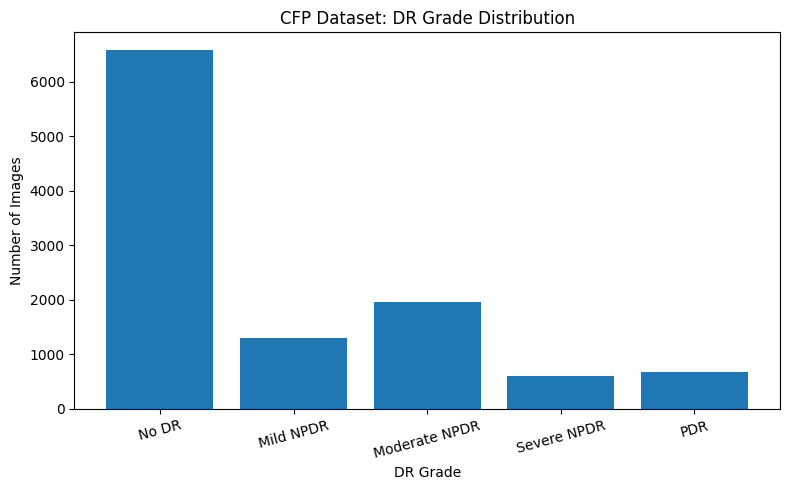

Grade distribution:


,image_count
grade,
0,6579
1,1302
2,1959
3,603
4,675


In [19]:
import matplotlib.pyplot as plt

grade_counts = cfp_clean["grade"].value_counts().sort_index()

grade_labels = {
    0: "No DR",
    1: "Mild NPDR",
    2: "Moderate NPDR",
    3: "Severe NPDR",
    4: "PDR"
}

plt.figure(figsize=(8, 5))

plt.bar(
    [grade_labels[i] for i in grade_counts.index],
    grade_counts.values
)

plt.xlabel("DR Grade")
plt.ylabel("Number of Images")
plt.title("CFP Dataset: DR Grade Distribution")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("Grade distribution:")
display(grade_counts.to_frame("image_count"))

,positive_images,percentage
microaneurysm,4398,39.56
hard_exudate,2648,23.82
intraretinal_hemorrhage,2580,23.21
vb_irma,236,2.12
neovascularization,556,5.00
vitreous_hemorrhage,358,3.22
retinal_detachment,93,0.84


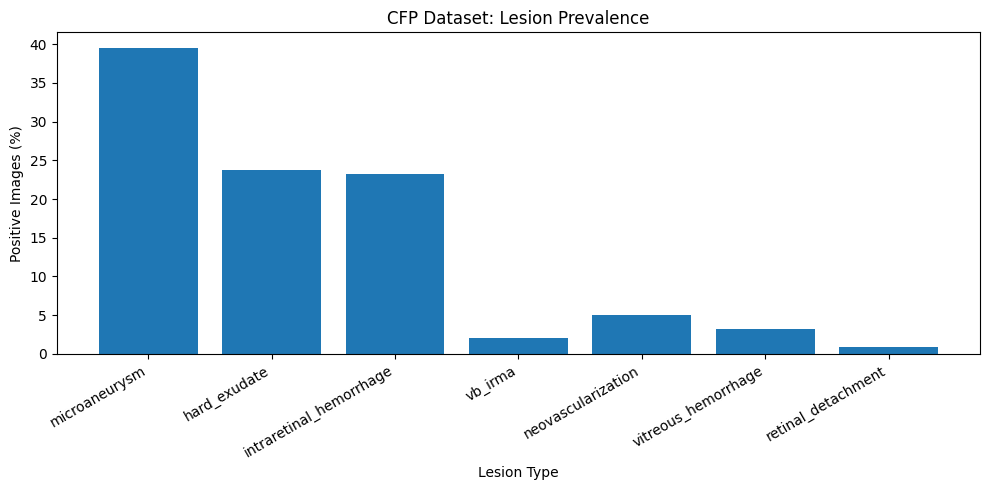

In [20]:
lesion_columns = [
    "microaneurysm",
    "hard_exudate",
    "intraretinal_hemorrhage",
    "vb_irma",
    "neovascularization",
    "vitreous_hemorrhage",
    "retinal_detachment"
]

lesion_counts = cfp_clean[lesion_columns].sum()
lesion_percentages = (lesion_counts / len(cfp_clean)) * 100

lesion_summary = pd.DataFrame({
    "positive_images": lesion_counts,
    "percentage": lesion_percentages.round(2)
})

display(lesion_summary)

plt.figure(figsize=(10, 5))

plt.bar(
    lesion_summary.index,
    lesion_summary["percentage"]
)

plt.xlabel("Lesion Type")
plt.ylabel("Positive Images (%)")
plt.title("CFP Dataset: Lesion Prevalence")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Lesion prevalence (%) across DR grades:


,microaneurysm,hard_exudate,intraretinal_hemorrhage,vb_irma,neovascularization,vitreous_hemorrhage,retinal_detachment
No DR,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Mild NPDR,100.00,41.24,0.00,0.00,0.00,0.00,0.00
Moderate NPDR,100.00,62.74,86.88,0.00,0.00,0.00,0.00
Severe NPDR,100.00,82.59,88.39,32.67,0.00,0.00,0.00
PDR,79.11,56.89,51.11,5.78,82.37,53.04,13.78


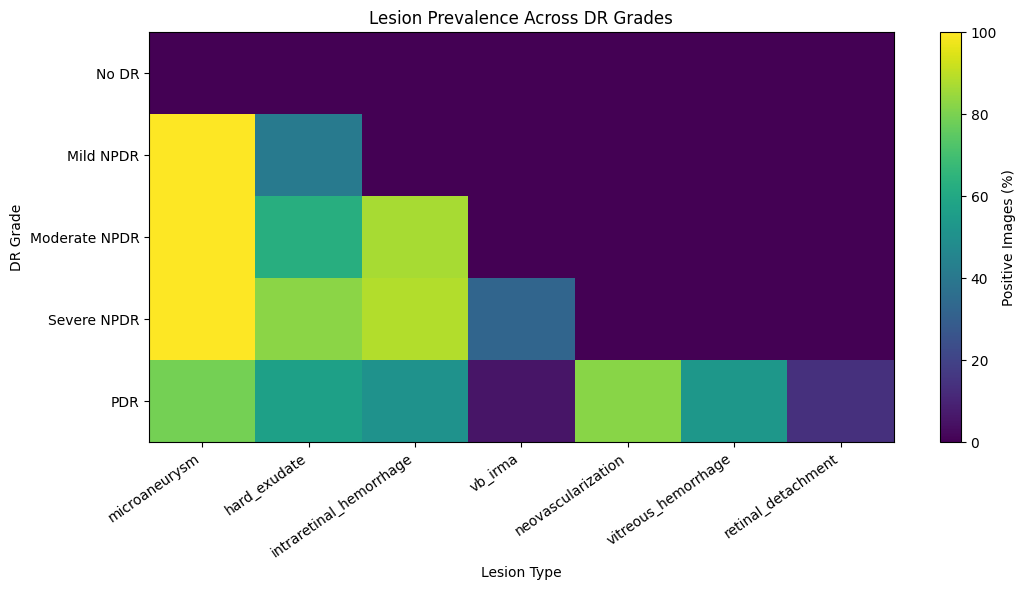

In [21]:
grade_lesion = (
    cfp_clean
    .groupby("grade")[lesion_columns]
    .mean() * 100
)

grade_lesion.index = [
    grade_labels[i] for i in grade_lesion.index
]

print("Lesion prevalence (%) across DR grades:")
display(grade_lesion.round(2))

plt.figure(figsize=(11, 6))

plt.imshow(
    grade_lesion.values,
    aspect="auto"
)

plt.colorbar(label="Positive Images (%)")

plt.xticks(
    range(len(lesion_columns)),
    lesion_columns,
    rotation=35,
    ha="right"
)

plt.yticks(
    range(len(grade_lesion.index)),
    grade_lesion.index
)

plt.xlabel("Lesion Type")
plt.ylabel("DR Grade")
plt.title("Lesion Prevalence Across DR Grades")

plt.tight_layout()
plt.show()

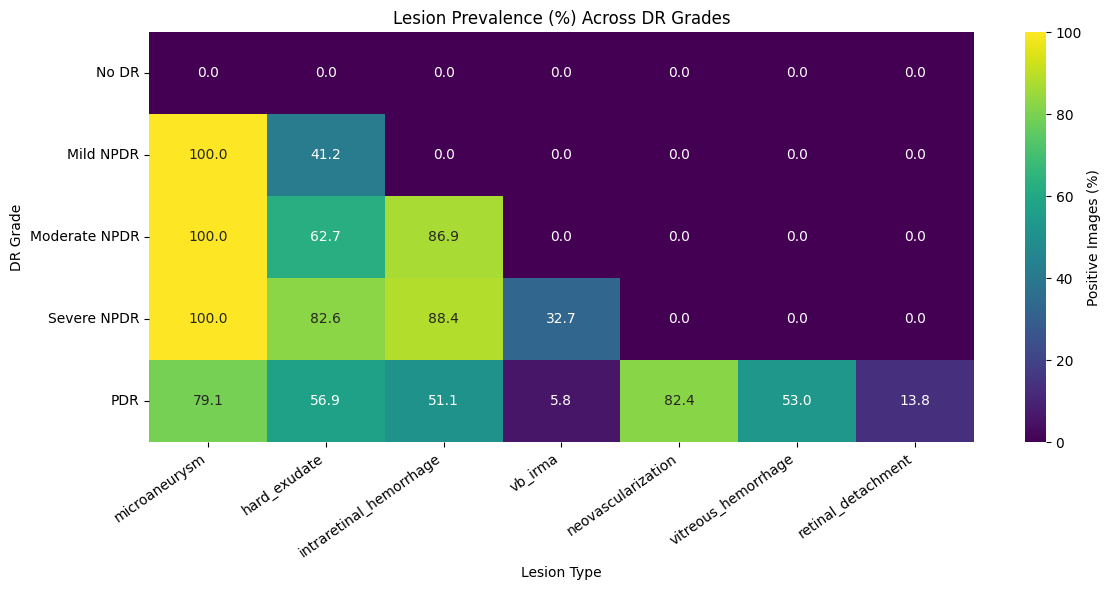

In [22]:
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.heatmap(
    grade_lesion,
    annot=True,
    fmt=".1f",
    cmap="viridis",
    cbar_kws={"label": "Positive Images (%)"}
)

plt.xlabel("Lesion Type")
plt.ylabel("DR Grade")
plt.title("Lesion Prevalence (%) Across DR Grades")

plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

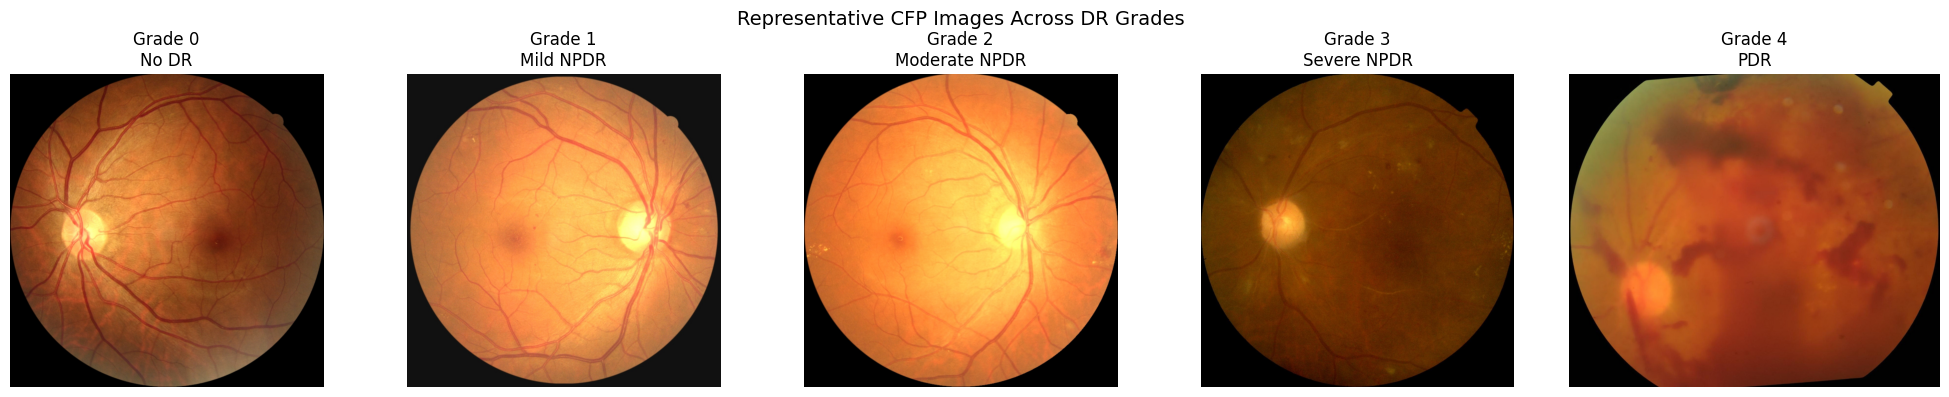

In [23]:
import os
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for grade in range(5):
    sample = cfp_clean[cfp_clean["grade"] == grade].sample(
        n=1,
        random_state=42
    ).iloc[0]

    image_path = os.path.join(IMAGE_ROOT, sample["image"])
    image = Image.open(image_path).convert("RGB")

    axes[grade].imshow(image)
    axes[grade].set_title(
        f"Grade {grade}\n{grade_labels[grade]}"
    )
    axes[grade].axis("off")

plt.suptitle(
    "Representative CFP Images Across DR Grades",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [24]:
grade_percentage = (
    cfp_clean["grade"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

imbalance_summary = pd.DataFrame({
    "grade": range(5),
    "label": [grade_labels[i] for i in range(5)],
    "image_count": grade_counts.values,
    "percentage": grade_percentage.round(2).values
})

display(imbalance_summary)

print(
    f"\nLargest class: Grade 0 ({grade_percentage[0]:.2f}%)"
)

print(
    f"Smallest class: Grade 3 ({grade_percentage[3]:.2f}%)"
)

,grade,label,image_count,percentage
0,0,No DR,6579,59.17
1,1,Mild NPDR,1302,11.71
2,2,Moderate NPDR,1959,17.62
3,3,Severe NPDR,603,5.42
4,4,PDR,675,6.07



Largest class: Grade 0 (59.17%)
Smallest class: Grade 3 (5.42%)


In [25]:
print("Duplicate image entries:", cfp_clean["image"].duplicated().sum())

print(
    "Invalid DR grades:",
    (~cfp_clean["grade"].isin([0, 1, 2, 3, 4])).sum()
)

print(
    "Unique image entries:",
    cfp_clean["image"].nunique()
)

print(
    "Total dataframe rows:",
    len(cfp_clean)
)

Duplicate image entries: 0
Invalid DR grades: 0
Unique image entries: 11118
Total dataframe rows: 11118


## 7. EDA Summary

The exploratory analysis of the CFP dataset reveals:

* The dataset contains **11,118 unique CFP images** with no duplicate image entries or invalid DR grades.
* DR grades are **imbalanced**, with Grade 0 (No DR) representing 59.17% of the dataset.
* Microaneurysm is the most prevalent lesion (39.56%), followed by hard exudate (23.82%) and intraretinal hemorrhage (23.21%).
* Lesion prevalence varies across DR severity grades, with several advanced lesions appearing more frequently in severe disease.
* Representative CFP images demonstrate visual differences across DR grades.
* These findings will be considered when designing the multi-task training strategy and handling class imbalance.
